In [2]:
import subprocess
import os
import shutil
from pathlib import Path
from Bio import SeqIO
import pandas as pd
import requests

### Create fasta files to run MMSEQS2

In [ ]:
skempi_data = pd.read_csv("/home/user/Documents/ProteinMPNN/datasets/SKEMPI2_filtered_final.csv") # ProtBFF CSV 
print(skempi_data.shape)
print(f"Number of unique PDB entries: {len(pdb_names)}")
skempi_data.head()

(6660, 7)
Number of unique PDB entries: 339


,#Pdb,#Pdb_origin,Partner1,Partner2,Mutation(s)_cleaned,ddG,Label
0,0_1CSE,1CSE,E,I,LI38G,2.280577,forward
1,1_1CSE,1CSE,E,I,LI38S,1.188776,forward
2,2_1CSE,1CSE,E,I,LI38P,6.765446,forward
3,3_1CSE,1CSE,E,I,LI38I,2.982502,forward
4,4_1CSE,1CSE,E,I,LI38D,4.411843,forward


In [155]:
## filter out multi-point mutations ##
# skempi_data['num_mutations'] = skempi_data['Mutation(s)_cleaned'].apply(lambda x: len(x.split(',')))
# skempi_filtered = skempi_data[skempi_data['num_mutations'] == 1]
# print(f"Number of single-point mutations: {skempi_filtered.shape[0]}")
# skempi_filtered.to_csv("/home/user/Documents/ProteinMPNN/datasets/SKEMPI2_single_point_filtered.csv", index=False)
skempi_filtered = pd.read_csv("/home/user/Documents/ProteinMPNN/datasets/SKEMPI2_single_point_filtered.csv")
pdb_names = skempi_filtered['Pdb_origin'].unique()
print(f"Number of unique PDB entries: {len(pdb_names)}")
print(skempi_filtered.shape)
skempi_filtered.head()

Number of unique PDB entries: 295
(4546, 9)


,Pdb,Pdb_origin,Partner1,Partner2,Mutation_cleaned,ddG,Label,num_mutations,pdb_sequence
0,0_1CSE,1CSE,E,I,LI38G,2.280577,forward,1,KSFPEVVGKTVDQAREYFTLHYPQYNVYFLPEGSPVTLDLRYNRVR...
1,1_1CSE,1CSE,E,I,LI38S,1.188776,forward,1,KSFPEVVGKTVDQAREYFTLHYPQYNVYFLPEGSPVTLDLRYNRVR...
2,2_1CSE,1CSE,E,I,LI38P,6.765446,forward,1,KSFPEVVGKTVDQAREYFTLHYPQYNVYFLPEGSPVTLDLRYNRVR...
3,3_1CSE,1CSE,E,I,LI38I,2.982502,forward,1,KSFPEVVGKTVDQAREYFTLHYPQYNVYFLPEGSPVTLDLRYNRVR...
4,4_1CSE,1CSE,E,I,LI38D,4.411843,forward,1,KSFPEVVGKTVDQAREYFTLHYPQYNVYFLPEGSPVTLDLRYNRVR...


In [152]:
names = skempi_filtered['Pdb_origin'].unique()
len(names)

295

In [106]:
# Fetch WT sequences of all unique proteins
wt_sequences = {}
for pdb_id in pdb_names:
    url = f'https://www.rcsb.org/fasta/entry/{pdb_id}/display'
    response = requests.get(url)
    # concat_seqs = ''
    chain_num = 0
    if response.status_code == 200:
        fasta_data = response.text
        lines = fasta_data.splitlines()
        for line in lines:
            if not line.startswith('>'):
                # concat_seqs += line.strip()
                wt_sequences[pdb_id + '_' + str(chain_num)] = line.strip()
                chain_num += 1
    else:
        print(f'Failed to fetch sequence for {pdb_id}')
        
print(len(wt_sequences))

813


In [107]:
# Save WT sequences to a FASTA file
count = 0
with open('/home/user/Documents/ProteinMPNN/dataset-filtering/cleaned_skempi2.fasta', 'w') as f:
    for pdb_id, sequence in wt_sequences.items():
        count += 1
        f.write(f'>{pdb_id}\n')
        f.write(f'{sequence}\n')
print(count)

813


#### Extract and save PDB sequences for all unique proteins

In [158]:
import sys
sys.path.append("/home/user/Documents/ProteinMPNN/")
from ddg_pipeline.protein_mpnn_utils import parse_PDB_biounits
import numpy as np

pdb_seq_dict = {}
pdb_dir = "/media/user/DATA/raghav/Documents/ProteinMPNN/SKEMPI2/filtered_PDBs/"

init_alphabet = ['A', 'B', 'C', 'D', 'E', 'F', 'G','H', 'I', 'J','K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T','U', 'V','W','X', 'Y', 'Z', 'a', 'b', 'c', 'd', 'e', 'f', 'g','h', 'i', 'j','k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't','u', 'v','w','x', 'y', 'z']
# extra_alphabet = [str(item) for item in list(np.arange(300))]
chain_alphabet = init_alphabet 
count = 0
for pdb_id in pdb_names:
    pdb_path = os.path.join(pdb_dir, f"{pdb_id}.pdb")
    if os.path.exists(pdb_path):
        for letter in chain_alphabet:
            xyz, seq = parse_PDB_biounits(pdb_path, chain=letter)
            if seq != 'no_chain' and len(seq[0]) > 0:
                pdb_seq_dict[pdb_id + '_' + letter] = seq[0] # store sequence for this chain
        count += 1
    else:
        print(f"PDB file not found for {pdb_id}")

print(count)

295


In [159]:
# Save PDB sequences to a FASTA file
count = 0
with open('/home/user/Documents/ProteinMPNN/dataset-filtering/cleaned_pdbseq_skempi2.fasta', 'w') as f:
    for pdb_id, sequence in pdb_seq_dict.items():
        count += 1
        f.write(f'>{pdb_id}\n')
        f.write(f'{sequence}\n')
print(count)

761


In [ ]:
## Add sequences to the dataframe and save ##
for idx, row in skempi_filtered.iterrows():
    pdb_id = row['Pdb_origin']
    mutation_info = row['Mutation_cleaned']
    chain_id = mutation_info[1] # get chain ID from mutation info
    key = pdb_id + '_' + chain_id
    if key in pdb_seq_dict:
        skempi_filtered.at[idx, 'pdb_sequence'] = pdb_seq_dict[key]
    else:
        print(f"Sequence not found for {key}")
        skempi_filtered.loc[idx, 'pdb_sequence'] = None

# skempi_filtered.to_csv("/home/user/Documents/ProteinMPNN/datasets/SKEMPI2_single_point_filtered.csv", index=False)
print(skempi_filtered['pdb_sequence'].nunique())
skempi_filtered.head()

NameError: name 'Skempi_filtered' is not defined

#### Running MMSeqs2 on the fasta files for clustering and generating train/test splits

In [163]:
def cluster_sequences(input_fasta, output_dir, min_seq_id=0.60, coverage=0.8, threads=8):
    input_fasta = Path(input_fasta)
    output_dir = Path(output_dir)
    output_dir.mkdir(exist_ok=True)
    tmp_dir = output_dir / 'tmp'
    tmp_dir.mkdir(exist_ok=True)

    if not input_fasta.exists():
        raise FileNotFoundError(f"Input FASTA not found: {input_fasta}")

    # Run easy-search
    subprocess.run([
        'mmseqs', 'easy-cluster', str(input_fasta), str(output_dir / 'cluster_result'), str(tmp_dir),
        '--min-seq-id', str(min_seq_id),
        '-c', str(coverage),
        '--cov-mode', '0',
        '--alignment-mode', '3',
        '--threads', str(threads)
    ], check=True)

    # Parse cluster results
    cluster_file = output_dir / 'cluster_result_cluster.tsv'
    if not cluster_file.exists():
        raise FileNotFoundError(f"Cluster result file not found: {cluster_file}")

In [164]:
results = cluster_sequences('cleaned_pdbseq_skempi2.fasta', 'dataset-filtering')

easy-cluster cleaned_pdbseq_skempi2.fasta dataset-filtering/cluster_result dataset-filtering/tmp --min-seq-id 0.6 -c 0.8 --cov-mode 0 --alignment-mode 3 --threads 8 

MMseqs Version:                     	18.8cc5c
Substitution matrix                 	aa:blosum62.out,nucl:nucleotide.out
Seed substitution matrix            	aa:VTML80.out,nucl:nucleotide.out
Sensitivity                         	4
k-mer length                        	0
Target search mode                  	0
k-score                             	seq:2147483647,prof:2147483647
Alphabet size                       	aa:21,nucl:5
Max sequence length                 	65535
Max results per query               	20
Split database                      	0
Split mode                          	2
Split memory limit                  	0
Coverage threshold                  	0.8
Coverage mode                       	0
Compositional bias                  	1
Compositional bias scale            	1
Diagonal scoring                    	true
Exact k-

In [165]:
## Merge Clusters That Share a Complex
def merge_clusters_by_complex(cluster_tsv):
    import pandas as pd
    from collections import defaultdict

    df = pd.read_csv(cluster_tsv, sep="\t", names=["representative", "member"]) 

    def get_PDBID(chain_id):
        return chain_id.rsplit("_", 1)[0]

    # Map each complex to all clusters its chains appear in
    complex_to_clusters = defaultdict(set)
    for _, row in df.iterrows():
        parent = get_PDBID(row["member"])
        complex_to_clusters[parent].add(row["representative"])

    # Union-Find to merge clusters that share a complex
    parent_map = {}

    def find(x):
        while parent_map.get(x, x) != x:  # .get(key, default value)
            parent_map[x] = parent_map.get(parent_map.get(x, x), x)
            x = parent_map.get(x, x)
        return x

    def union(a, b):
        a, b = find(a), find(b)
        if a != b:
            parent_map[b] = a

    # Merge all clusters that share a complex
    for complex_id, clusters in complex_to_clusters.items():
        clusters = list(clusters)
        for i in range(1, len(clusters)):
            union(clusters[0], clusters[i])

    # Assign each complex to its merged cluster
    complex_to_merged_cluster = {}
    for complex_id, clusters in complex_to_clusters.items():
        merged = find(list(clusters)[0])
        complex_to_merged_cluster[complex_id] = merged

    # Invert mapping to merged_cluster -> list of complexes
    merged_to_complexes = defaultdict(list)
    for complex_id, merged in complex_to_merged_cluster.items():
        merged_to_complexes[merged].append(complex_id)

    return dict(merged_to_complexes)


In [166]:
final_clusters = merge_clusters_by_complex("/home/user/Documents/ProteinMPNN/dataset-filtering/dataset-filtering/cluster_result_cluster.tsv")

In [167]:
len(final_clusters.keys())

132

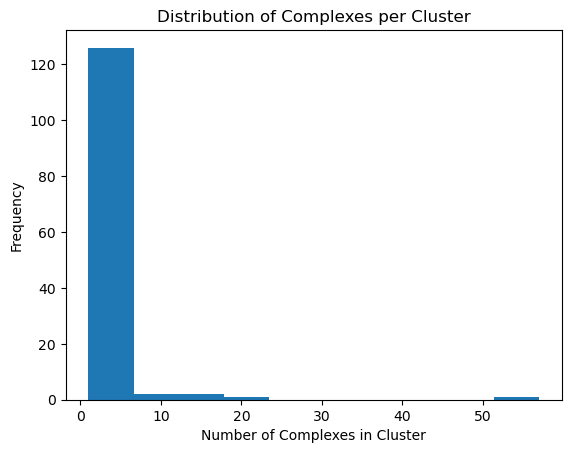

In [168]:
import matplotlib.pyplot as plt

prot_distr = [len(complexes) for complexes in final_clusters.values()]
plt.hist(prot_distr, bins=10)
plt.xlabel('Number of Complexes in Cluster')
plt.ylabel('Frequency')
plt.title('Distribution of Complexes per Cluster')
plt.show()

In [169]:
## Creating train/val/test splits ##
import pandas as pd
import numpy as np
from Bio import SeqIO

representatives = list(final_clusters.keys())
np.random.seed(42)
np.random.shuffle(representatives)

n = len(representatives)
n_train = int(0.8 * n)
n_val   = int(0.1 * n)

train_reps = representatives[:n_train]
val_reps   = representatives[n_train:n_train + n_val]
test_reps  = representatives[n_train + n_val:]

def get_complexes(reps, cluster_map):
    complexes = set()
    for r in reps:
        complexes.update(cluster_map[r])
    return complexes

train_complexes = get_complexes(train_reps, final_clusters)
val_complexes   = get_complexes(val_reps,   final_clusters)
test_complexes  = get_complexes(test_reps,  final_clusters)

print(f"Clusters  - Train: {len(train_reps)}, Val: {len(val_reps)}, Test: {len(test_reps)}")
print(f"Complexes - Train: {len(train_complexes)}, Val: {len(val_complexes)}, Test: {len(test_complexes)}")

Clusters  - Train: 105, Val: 13, Test: 14
Complexes - Train: 238, Val: 35, Test: 22


In [170]:
import pickle

skempi2_splits = {
    'train': np.array(sorted(train_complexes)),
    'val': np.array(sorted(val_complexes)),
    'test': np.array(sorted(test_complexes))
}

with open('/home/user/Documents/ProteinMPNN/dataset-filtering/skempi2_pdb_seqs_splits.pkl', 'wb') as f:
    pickle.dump(skempi2_splits, f)

#### Running MMSeqs2 on the fasta files for removing homologous sequences from training set

In [ ]:
## For a single benchmarking and training set.
def remove_homologs(benchmark_fasta, train_fasta, output_fasta, min_seq_id=0.25, coverage=0.8, threads=8):
    benchmark_fasta = Path(benchmark_fasta)
    train_fasta = Path(train_fasta)
    output_fasta = Path(output_fasta)
    tmp_dir = Path("/home/user/Documents/ProteinMPNN/dataset-filtering/mmseqs_tmp")
    tmp_dir.mkdir(exist_ok=True)
    result_tsv = tmp_dir / "homologs.tsv"

    if not benchmark_fasta.exists():
        raise FileNotFoundError(f"Benchmark FASTA not found: {benchmark_fasta}")
    if not train_fasta.exists():
        raise FileNotFoundError(f"Training FASTA not found: {train_fasta}")

    mmseqs_bin = shutil.which("mmseqs")
    if mmseqs_bin is None:
        raise FileNotFoundError(
            "mmseqs was not found on PATH in this notebook environment. "
            "Install mmseqs2 in the same environment/kernel or add the mmseqs binary to PATH."
        )

    # Run easy-search: query = benchmark set, target = training set.
    subprocess.run([
        mmseqs_bin, "easy-search",
        str(benchmark_fasta), str(train_fasta), str(result_tsv), str(tmp_dir),
        "--min-seq-id", str(min_seq_id),
        "-c", str(coverage),
        "--cov-mode", "0",
        "--alignment-mode", "3",
        "--format-output", "query,target,pident",
        "--threads", str(threads),
    ], check=True)

    contaminated = set() # stores the IDs of training sequences that are homologous to any benchmark sequence
    if result_tsv.exists():
        with result_tsv.open() as f:
            for line in f:
                parts = line.rstrip("\n").split("\t")
                if len(parts) >= 3 and float(parts[2]) >= min_seq_id * 100:
                    contaminated.add(parts[1])

    records = list(SeqIO.parse(str(train_fasta), "fasta"))
    clean = [record for record in records if record.id not in contaminated]
    SeqIO.write(clean, str(output_fasta), "fasta")

    print(f"Removed {len(contaminated)} homologs, {len(clean)} sequences remain")
    print(f"Wrote cleaned FASTA to: {output_fasta}")
    return clean

In [11]:
clean_result = remove_homologs(
    benchmark_fasta="benchmark_combined.fasta",
    train_fasta="mega_train.fasta",
    output_fasta="comb_train_clean.fasta",
)

/home/user/Documents/ProteinMPNN/dataset-filtering/mmseqs_tmp/homologs.tsv exists and will be overwritten
easy-search benchmark_combined.fasta mega_train.fasta /home/user/Documents/ProteinMPNN/dataset-filtering/mmseqs_tmp/homologs.tsv /home/user/Documents/ProteinMPNN/dataset-filtering/mmseqs_tmp --min-seq-id 0.25 -c 0.8 --cov-mode 0 --alignment-mode 3 --format-output query,target,pident --threads 8 

MMseqs Version:                        	18.8cc5c
Substitution matrix                    	aa:blosum62.out,nucl:nucleotide.out
Add backtrace                          	false
Alignment mode                         	3
Alignment mode                         	0
Allow wrapped scoring                  	false
E-value threshold                      	0.001
Seq. id. threshold                     	0.25
Min alignment length                   	0
Seq. id. mode                          	0
Alternative alignments                 	0
Coverage threshold                     	0.8
Coverage mode                     

In [129]:
df = pd.read_csv("/home/user/Documents/ProteinMPNN/datasets/SKEMPI2_single_point_filtered.csv")
wt_name = '3HFM'
wt_seqs = {}
data = df.query('Pdb_origin == @wt_name').reset_index(drop=True)
wt_seqs.update({
    f'{wt_name}_{ch_id}': seq
    for ch_id, seq in zip(
        data['Mutation_cleaned'].str[1],
        data['pdb_sequence']
    )
})
wt_seqs

{'3HFM_Y': 'KVFGRCELAAAMKRHGLDNYRGYSLGNWVCAAKFESNFNTQATNRNTDGSTDYGILQINSRWWCNDGRTPGSRNLCNIPCSALLSSDITASVNCAKKIVSDGNGMNAWVAWRNRCKGTDVQAWIRGCRL',
 '3HFM_L': 'DIVLTQSPATLSVTPGNSVSLSCRASQSIGNNLHWYQQKSHESPRLLIKYASQSISGIPSRFSGSGSGTDFTLSINSVETEDFGMYFCQQSNSWPYTFGGGTKLEIKRADAAPTVSIFPPSSEQLTSGGASVVCFLNNFYPKDINVKWKIDGSERQNGVLNSWTDQDSKDSTYSMSSTLTLTKDEYERHNSYTCEATHKTSTSPIVKSFNRNEC',
 '3HFM_H': 'DVQLQESGPSLVKPSQTLSLTCSVTGDSITSDYWSWIRKFPGNRLEYMGYVSYSGSTYYNPSLKSRISITRDTSKNQYYLDLNSVTTEDTATYYCANWDGDYWGQGTLVTVSAAKTTPPSVYPLAPGSAAQTNSMVTLGCLVKGYFPEPVTVTWNSGSLSSGVHTFPAVLQSDLYTLSSSVTVPSSPRPSETVTCNVAHPASSTKVDKKIVPRDC'}

In [120]:
import pickle

with open('/home/user/Documents/ProteinMPNN/dataset-filtering/skempi2_pdb_seqs_splits.pkl', 'rb') as f:
    splits = pickle.load(f)

len(splits['train'])

273

In [149]:
np.where(splits['train'] == '1Z7X')[0]
splits['train'][1]

'1A4Y'

In [137]:
chain_col = df['Mutation_cleaned'].str[1]
chain_labels = chain_col.unique()
chain_labels

array(['I', 'A', 'D', 'B', 'C', 'N', 'U', 'P', 'E', 'H', 'W', 'L', 'T',
       'Y', 'Q', 'G', 'M'], dtype=object)

In [138]:
rows = df[chain_col == 'W']
rows

,Pdb,Pdb_origin,Partner1,Partner2,Mutation_cleaned,ddG,Label,num_mutations,pdb_sequence
954,1366_1Z7X,1Z7X,W,X,YW434A,5.955931,forward,1,SLDIQSLDIQCEELSDARWAELLPLLQQCQVVRLDDCGLTEARCKD...
955,1367_1Z7X,1Z7X,W,X,DW435A,3.662431,forward,1,SLDIQSLDIQCEELSDARWAELLPLLQQCQVVRLDDCGLTEARCKD...
956,1368_1Z7X,1Z7X,W,X,YW437A,2.624135,forward,1,SLDIQSLDIQCEELSDARWAELLPLLQQCQVVRLDDCGLTEARCKD...
957,1371_1Z7X,1Z7X,W,X,RW457A,0.848247,forward,1,SLDIQSLDIQCEELSDARWAELLPLLQQCQVVRLDDCGLTEARCKD...
958,1372_1Z7X,1Z7X,W,X,IW459A,0.337421,forward,1,SLDIQSLDIQCEELSDARWAELLPLLQQCQVVRLDDCGLTEARCKD...
961,1377_1Z7X,1Z7X,W,X,EW206A,1.018685,forward,1,SLDIQSLDIQCEELSDARWAELLPLLQQCQVVRLDDCGLTEARCKD...
962,1378_1Z7X,1Z7X,W,X,WW261A,1.335954,forward,1,SLDIQSLDIQCEELSDARWAELLPLLQQCQVVRLDDCGLTEARCKD...
963,1379_1Z7X,1Z7X,W,X,WW263A,2.212418,forward,1,SLDIQSLDIQCEELSDARWAELLPLLQQCQVVRLDDCGLTEARCKD...
964,1380_1Z7X,1Z7X,W,X,EW287A,1.321325,forward,1,SLDIQSLDIQCEELSDARWAELLPLLQQCQVVRLDDCGLTEARCKD...
965,1381_1Z7X,1Z7X,W,X,SW289A,0.814384,forward,1,SLDIQSLDIQCEELSDARWAELLPLLQQCQVVRLDDCGLTEARCKD...


In [132]:
lol = {'test': df.query('Pdb_origin == @wt_name').reset_index(drop=True)}
lol

{'test':           Pdb Pdb_origin Partner1 Partner2 Mutation_cleaned       ddG  \
 0   2146_3HFM       3HFM       HL        Y            YY20A  4.878217   
 1   2147_3HFM       3HFM       HL        Y            NL32A  5.109633   
 2   2149_3HFM       3HFM       HL        Y            KY96A  6.991293   
 3   2150_3HFM       3HFM       HL        Y            NL31A  5.216466   
 4   2152_3HFM       3HFM       HL        Y            NL31D  1.344086   
 ..        ...        ...      ...      ...              ...       ...   
 91  2263_3HFM       3HFM       HL        Y           SY100A  0.267779   
 92  2264_3HFM       3HFM       HL        Y           DY101A  0.953515   
 93  2265_3HFM       3HFM       HL        Y            YY20F -0.463747   
 94  2266_3HFM       3HFM       HL        Y            YY20L  2.185484   
 95  2267_3HFM       3HFM       HL        Y            KY96R  5.355400   
 
       Label  num_mutations                                       pdb_sequence  
 0   forward         